In [1]:
import os
import json
import math
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import numpy as np

In [2]:
columns = ["Who", "Action", "Round", "AgentAUtility", "AgentBUtility", "NashDistance"]

In [3]:
# =============================================================================
# COLOR SCHEME — Wong's colorblind-safe palette + extras, deterministic by name
# =============================================================================
# Reference: Wong, B. (2011). Points of view: Color blindness. Nature Methods 8, 441.
# Auto-assigns a color to every agent that appears in the data — no hardcoded
# agent list. Call `set_agents(...)` once after loading results.

_PALETTE = [
    '#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9',
    '#F0E442', '#000000', '#8B4513', '#2F4F4F', '#800080', '#7F7F7F',
    '#1F77B4', '#2CA02C', '#9467BD', '#17BECF', '#BCBD22', '#E377C2',
]

agents: list = []
_color_map: dict = {}


def set_agents(agent_list):
    """Register the agents to plot. Sets the global `agents` list (sorted)
    and a deterministic agent → color map. Re-callable to reset between runs."""
    global agents, _color_map
    agents = sorted(agent_list)
    _color_map = {a: _PALETTE[i % len(_PALETTE)] for i, a in enumerate(agents)}


def get_agent_color(agent_name):
    """Color for an agent. Falls back to gray for anything not registered."""
    return _color_map.get(agent_name, '#808080')


def get_agent_colors_list(agent_list):
    return [get_agent_color(a) for a in agent_list]

# Helper Methods

In [4]:
def load_domain_disagreement_result(domain: str):
    spec_file = f"../main/domains/domain{domain}/specs.json"
    with open(spec_file, "r") as f:
        spec = json.load(f)

    agent_A_reservation_value = spec.get("ReservationValueProfileA", 0.0)
    agent_B_reservation_value = spec.get("ReservationValueProfileB", 0.0)

    nash_bid = (spec["Nash_A"], spec["Nash_B"])
    nash_distance = math.sqrt(
        (nash_bid[0] - agent_A_reservation_value) ** 2
        + (nash_bid[1] - agent_B_reservation_value) ** 2
    )
    return agent_A_reservation_value, agent_B_reservation_value, nash_distance


def nash_distance_for_row(row, nash_a, nash_b):
    return math.sqrt(
        (row["AgentAUtility"] - nash_a) ** 2
        + (row["AgentBUtility"] - nash_b) ** 2
    )

In [5]:
import re

# tournament.py writes filenames as `{kindA}-{idA}_vs_{kindB}-{idB}.xlsx`
# inside a per-domain folder: session_logs/{domain}/...
# kind ∈ {LLM, META, TRAD, ADV}. The ADV side keeps its display name verbatim
# (e.g. "Adversary-threat") with no "ADV-" prefix.
_FILENAME_RE = re.compile(r"^(?P<a>.+)_vs_(?P<b>.+)\.xlsx$")
_KIND_PREFIXES = ("LLM-", "META-", "TRAD-")


def _split_kind(label):
    if label == "Council":
        # Council label has no kind prefix and no model identifier; the
        # whole label IS the display name for this kind.
        return "COUNCIL", "Council"
    if label.startswith("Adversary-"):
        # Adversary label has no kind prefix; whole thing IS the display name.
        return "ADV", label[len("Adversary-"):]
    for prefix in _KIND_PREFIXES:
        if label.startswith(prefix):
            return prefix.rstrip("-"), label[len(prefix):]
    raise ValueError(f"Unrecognized agent label: {label!r}")


# Paper-ready display names for the LLMs we report on. Keyed by the
# trailing segment of the identifier after the last underscore (i.e. the
# tail of the original `provider/family/model` string).
_LLM_DISPLAY_NAMES = {
    "claude-sonnet-4.6":   "Opus 4.7",
    "gpt-5.5":             "GPT-5.5",
    "gemini-pro-latest":   "Gemini Pro 3.1",
    "gpt-4o-2024-08-06": "GPT-4o",
}

# Paper-ready display names for the six adversary personas. Keyed by the
# persona identifier left over after _split_kind strips the "Adversary-"
# prefix from the filename label.
_ADVERSARY_DISPLAY_NAMES = {
    "threat":      "Coercive Threat",
    "emotional":   "Emotional Appeal",
    "positive":    "Deceptive Cooperation",
    "constraints": "Fabricated Constraints",
    "urgency":     "Manufactured Urgency",
    "injection":   "Prompt Injection",
}


def _agent_name(kind, ident):
    """Display name for an agent — no kind prefix.

    LLM/META: trailing segment after the last "/" mapped through
              `_LLM_DISPLAY_NAMES` for paper-friendly aliases (falls back
              to the raw segment if not mapped).
    TRAD:     the trad agent's display name as-is (e.g. 'Boulware').
    ADV:      mapped through `_ADVERSARY_DISPLAY_NAMES` for the six paper
              personas. Unmapped personas (e.g. legacy 'aggression' runs)
              fall back to 'Adversary-{ident}' so they stay self-identifying
              and naturally drop out of canonical-order column lists.
    COUNCIL:  'Council' (single artifact, no per-side identifier).
    """
    if kind == "COUNCIL":
        return "Council"
    if kind in ("LLM", "META"):
        short = ident.rsplit("_", 1)[-1]
        return _LLM_DISPLAY_NAMES.get(short, short)
    if kind == "ADV":
        return _ADVERSARY_DISPLAY_NAMES.get(ident, f"Adversary-{ident}")
    return ident


def process_session(file_path):
    """Read one session xlsx and return its final summary as a Series.

    Domain is derived from the parent folder name (e.g. session_logs/domain5/...).
    Adds `Agent_A_kind` / `Agent_B_kind` columns so downstream code can filter
    by agent kind without doing string-prefix matching on display names.
    """
    file_name = file_path.name
    m = _FILENAME_RE.match(file_name)
    if not m:
        return None

    kind_a, id_a = _split_kind(m.group("a"))
    kind_b, id_b = _split_kind(m.group("b"))
    agent_a = _agent_name(kind_a, id_a)
    agent_b = _agent_name(kind_b, id_b)

    raw_domain = file_path.parent.name
    domain_match = re.match(r"domain(\d+)", raw_domain)
    domain = domain_match.group(1) if domain_match else raw_domain

    try:
        df = pd.read_excel(file_path, sheet_name="Session")
    except Exception:
        return None
    if df.empty:
        return None

    a_res, b_res, _disagreement_dist = load_domain_disagreement_result(domain)
    spec_path = f"../main/domains/domain{domain}/specs.json"
    with open(spec_path, "r") as f:
        spec = json.load(f)
    nash_a, nash_b = spec["Nash_A"], spec["Nash_B"]

    if df.iloc[-1]["Action"] == "Accept":
        last_offer = df.iloc[-1].copy()
        action = "Accept"
        nash_dist = nash_distance_for_row(last_offer, nash_a, nash_b)
    else:
        last_offer = df.iloc[-1].copy()
        last_offer["AgentAUtility"] = a_res
        last_offer["AgentBUtility"] = b_res
        nash_dist = math.sqrt((nash_a - a_res) ** 2 + (nash_b - b_res) ** 2)
        action = "Failed"

    last_offer["NashDistance"] = nash_dist
    last_offer["Action"] = action
    last_offer["Agent_A"] = agent_a
    last_offer["Agent_B"] = agent_b
    last_offer["Agent_A_kind"] = kind_a
    last_offer["Agent_B_kind"] = kind_b
    last_offer["Domain"] = domain
    return last_offer


In [6]:
def load_tournament_results(base_dirs, n_jobs=8):
    """Walk one or more tournament directories for session xlsx files and
    return `{domain → DataFrame}`. Pass a single dir or a list of dirs."""
    if isinstance(base_dirs, (str, Path)):
        base_dirs = [base_dirs]

    files = []
    for base in base_dirs:
        files.extend(Path(base).rglob("*.xlsx"))

    if not files:
        return {}

    results = Parallel(n_jobs=n_jobs)(
        delayed(process_session)(f) for f in tqdm(files, desc="Sessions")
    )
    results = [r for r in results if r is not None]
    df = pd.DataFrame(results)
    return {
        d: df[df["Domain"] == d].reset_index(drop=True)
        for d in sorted(df["Domain"].unique())
    }

In [7]:
def aggregate_summary_statistics(df, agent_list=None):
    """Per-agent summary stats. Defaults to every agent appearing in `df`."""
    if agent_list is None:
        agent_list = sorted(set(df["Agent_A"]).union(df["Agent_B"]))

    summary_df = pd.DataFrame()
    for agent in agent_list:
        agent_a_df = df[df["Agent_A"] == agent]
        agent_b_df = df[df["Agent_B"] == agent]

        all_agent_utility = pd.concat([agent_a_df["AgentAUtility"], agent_b_df["AgentBUtility"]])
        all_opponent_utility = pd.concat([agent_a_df["AgentBUtility"], agent_b_df["AgentAUtility"]])

        summary_df.loc[agent, "AgentUtility_mean"] = all_agent_utility.mean()
        summary_df.loc[agent, "AgentUtility_std"] = all_agent_utility.std()
        summary_df.loc[agent, "AgentUtility_median"] = all_agent_utility.median()
        summary_df.loc[agent, "OpponentUtility_mean"] = all_opponent_utility.mean()
        summary_df.loc[agent, "OpponentUtility_std"] = all_opponent_utility.std()
        summary_df.loc[agent, "OpponentUtility_median"] = all_opponent_utility.median()

        agent_df = df[(df["Agent_A"] == agent) | (df["Agent_B"] == agent)]
        for col in ["NashDistance", "Round"]:
            if col in df.columns:
                summary_df.loc[agent, f"{col}_mean"] = agent_df[col].mean()
                summary_df.loc[agent, f"{col}_std"] = agent_df[col].std()
                summary_df.loc[agent, f"{col}_median"] = agent_df[col].median()

        summary_df.loc[agent, "AcceptanceRate"] = (
            len(agent_df[agent_df["Action"] == "Accept"]) / len(agent_df)
            if len(agent_df) else float("nan")
        )
    return summary_df

In [8]:
def display_mean_std(df, agent_list=None, sort_by=None, ascending=True, decimals=3):
    """Per-agent table where each numeric metric is rendered as 'mean ± std'.

    Wraps `aggregate_summary_statistics`. Returns a DataFrame whose rows are
    agents and whose columns are 'AgentUtility', 'OpponentUtility',
    'NashDistance', 'Round', 'AcceptanceRate' — the mean / std pairs from
    the underlying summary collapsed into one human-readable string per cell.

    Pass `sort_by="NashDistance"` (or any other base metric name) to sort by
    the underlying numeric mean before string-formatting.
    """
    summary = aggregate_summary_statistics(df, agent_list)
    if sort_by is not None and f"{sort_by}_mean" in summary.columns:
        summary = summary.sort_values(by=f"{sort_by}_mean", ascending=ascending)

    out = pd.DataFrame(index=summary.index)
    for base in ["AgentUtility", "OpponentUtility", "NashDistance", "Round"]:
        m_col, s_col = f"{base}_mean", f"{base}_std"
        if m_col in summary.columns and s_col in summary.columns:
            out[base] = [
                f"{m:.{decimals}f} ± {s:.{decimals}f}"
                if pd.notna(m) and pd.notna(s) else "—"
                for m, s in zip(summary[m_col], summary[s_col])
            ]
    if "AcceptanceRate" in summary.columns:
        out["AcceptanceRate"] = [
            f"{v:.{decimals}f}" if pd.notna(v) else "—"
            for v in summary["AcceptanceRate"]
        ]
    return out


def mean_std_pivot(df, row_col, col_col, value_col, row_order=None,
                   col_order=None, decimals=3):
    """Pivot: each cell is 'mean(value_col) ± std(value_col)' for the
    (row, col) group. Used by the adversary-robustness section to lay out
    LLM × opponent tables.
    """
    rows = row_order if row_order is not None else sorted(df[row_col].unique())
    cols = col_order if col_order is not None else sorted(df[col_col].unique())
    out = pd.DataFrame(index=rows, columns=list(cols), dtype=object)
    for r in rows:
        for c in cols:
            sub = df[(df[row_col] == r) & (df[col_col] == c)][value_col]
            if len(sub):
                out.loc[r, c] = f"{sub.mean():.{decimals}f} ± {sub.std():.{decimals}f}"
            else:
                out.loc[r, c] = "—"
    return out


# Visualizations

In [9]:
import seaborn as sns

_METRIC_CONFIG = {
    "utility": {
        "label": "Self Utility",
        "title": "Agent Utility",
        "cmap": "rocket",
        "vmin": 0.0,
        "vmax": 1.0,
        "sort_descending": True,
        "agent_a_col": "AgentAUtility",
        "agent_b_col": "AgentBUtility",
    },
    "nash": {
        "label": "Nash Distance",
        "title": "Nash Distance",
        "cmap": "rocket_r",
        "vmin": None,
        "vmax": None,
        "sort_descending": False,
        "agent_a_col": "NashDistance",
        "agent_b_col": "NashDistance",
    },
    "round": {
        "label": "Acceptance Round",
        "title": "Acceptance Round",
        "cmap": "rocket_r",
        "vmin": None,
        "vmax": None,
        "sort_descending": False,
        "agent_a_col": "Round",
        "agent_b_col": "Round",
    },
}


def _aggregate_pair_metric(df, agent, opponent, metric):
    config = _METRIC_CONFIG[metric]
    mask_a = (df["Agent_A"] == agent) & (df["Agent_B"] == opponent)
    vals_a = df.loc[mask_a, config["agent_a_col"]]
    mask_b = (df["Agent_B"] == agent) & (df["Agent_A"] == opponent)
    vals_b = df.loc[mask_b, config["agent_b_col"]]
    combined = pd.concat([vals_a, vals_b])
    return combined.mean() if len(combined) else np.nan


def _aggregate_agent_metric(df, agent, metric):
    config = _METRIC_CONFIG[metric]
    mask_a = df["Agent_A"] == agent
    vals_a = df.loc[mask_a, config["agent_a_col"]]
    mask_b = df["Agent_B"] == agent
    vals_b = df.loc[mask_b, config["agent_b_col"]]
    combined = pd.concat([vals_a, vals_b])
    return combined.mean() if len(combined) else np.nan


def plot_metric_heatmap(overall_df, metric="utility"):
    config = _METRIC_CONFIG[metric]

    matrix = np.full((len(agents), len(agents)), np.nan)
    for i, agent in enumerate(agents):
        for j, opponent in enumerate(agents):
            matrix[i, j] = _aggregate_pair_metric(overall_df, agent, opponent, metric)

    # Sort both axes by mean across opponents (matches the summary table's order).
    row_mean = np.nanmean(matrix, axis=1)
    sort_idx = np.argsort(row_mean)
    if config["sort_descending"]:
        sort_idx = sort_idx[::-1]
    sorted_agents_list = [agents[i] for i in sort_idx]
    sorted_matrix = matrix[sort_idx, :][:, sort_idx]

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(sorted_matrix, annot=True, fmt='.2f', cmap=config["cmap"],
                xticklabels=sorted_agents_list, yticklabels=sorted_agents_list,
                ax=ax, cbar_kws={'label': config["label"]},
                vmin=config["vmin"], vmax=config["vmax"],
                annot_kws={'fontsize': 11, 'weight': 'bold'},
                linewidths=0.5, linecolor='white')

    ax.set_xlabel('Opponent', fontsize=20, fontweight='bold', labelpad=10)
    ax.set_ylabel('Agent', fontsize=20, fontweight='bold', labelpad=10)
    ax.tick_params(axis='x', rotation=45, labelsize=16)
    ax.tick_params(axis='y', rotation=0, labelsize=16)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    plt.setp(ax.get_xticklabels(), ha='right')

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(config["label"], fontsize=18, fontweight='bold')

    plt.tight_layout()
    plt.close()
    return fig

In [10]:
def plot_metric_per_domain_heatmap(overall_df, metric="utility"):
    config = _METRIC_CONFIG[metric]

    raw_domains = list(overall_df["Domain"].unique())
    def _domain_sort_key(d):
        s = str(d)
        return (0, int(s)) if s.isdigit() else (1, s)
    domains_list = sorted(raw_domains, key=_domain_sort_key)

    matrix = np.full((len(agents), len(domains_list)), np.nan)

    for j, domain in enumerate(domains_list):
        domain_df = overall_df[overall_df["Domain"] == domain]
        for i, agent in enumerate(agents):
            matrix[i, j] = _aggregate_agent_metric(domain_df, agent, metric)

    row_median = np.nanmedian(matrix, axis=1)
    sort_idx = np.argsort(row_median)
    if config["sort_descending"]:
        sort_idx = sort_idx[::-1]
    sorted_agents_list = [agents[i] for i in sort_idx]
    sorted_matrix = matrix[sort_idx, :]

    fig_width = max(10, 1.0 * len(domains_list))
    fig, ax = plt.subplots(figsize=(fig_width, 10))
    sns.heatmap(sorted_matrix, annot=True, fmt='.2f', cmap=config["cmap"],
                xticklabels=[f"D{d}" for d in domains_list], yticklabels=sorted_agents_list,
                ax=ax, cbar_kws={'label': config["label"]},
                vmin=config["vmin"], vmax=config["vmax"],
                annot_kws={'fontsize': 10, 'weight': 'bold'},
                linewidths=0.5, linecolor='white')

    ax.set_xlabel('Domain', fontsize=20, fontweight='bold', labelpad=10)
    ax.set_ylabel('Agent', fontsize=20, fontweight='bold', labelpad=10)
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', rotation=0, labelsize=16)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    plt.setp(ax.get_xticklabels(), ha='right')

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(config["label"], fontsize=18, fontweight='bold')

    plt.tight_layout()
    plt.close()
    return fig

In [11]:
def plot_acceptance_rate_bar(overall_df):
    """Bar graph of acceptance rate for each agent."""
    acceptance_rates = []
    for agent in agents:
        agent_mask = (overall_df["Agent_A"] == agent) | (overall_df["Agent_B"] == agent)
        agent_games = overall_df.loc[agent_mask]
        total_games = len(agent_games)
        accepted_games = len(agent_games[agent_games["Action"] == "Accept"])
        acceptance_rates.append(accepted_games / total_games if total_games > 0 else 0)

    bar_colors = [get_agent_color(agent) for agent in agents]

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(agents, acceptance_rates, color=bar_colors,
                  edgecolor='black', linewidth=2, alpha=0.8)
    ax.set_xlabel('Agent', fontsize=22, fontweight='bold', labelpad=12)
    ax.set_ylabel('Acceptance Rate', fontsize=22, fontweight='bold', labelpad=12)
    ax.tick_params(axis='x', rotation=45, labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    plt.setp(ax.get_xticklabels(), ha='right')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3, linewidth=1.5)

    for bar, rate in zip(bars, acceptance_rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{rate:.2f}', ha='center', va='bottom',
                fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.close()
    return fig

In [12]:
def plot_acceptance_rounds_boxplot(acceptance_df):
    """Box plots of the round number at which acceptance happened for each agent, sorted by mean."""
    agent_stats = []
    
    # 1. Collect data and calculate means
    for agent in agents: # Assumes 'agents' is defined globally as in your original code
        agent_mask = (acceptance_df["Agent_A"] == agent) | (acceptance_df["Agent_B"] == agent)
        rounds = acceptance_df.loc[agent_mask, "Round"]
        
        # Calculate mean, default to infinity if empty so they sort to the end
        mean_val = rounds.mean() if not rounds.empty else float('inf') 
        
        agent_stats.append({
            'agent': agent,
            'rounds': rounds.values,
            'mean': mean_val
        })
        
    # 2. Sort the list of dictionaries by the 'mean' key
    agent_stats.sort(key=lambda x: x['mean'])
    
    # 3. Unpack the sorted data
    sorted_agents = [stat['agent'] for stat in agent_stats]
    data_to_plot = [stat['rounds'] for stat in agent_stats]
    
    # Ensure colors map to the newly sorted agents
    agent_colors = [get_agent_color(agent) for agent in sorted_agents]

    fig, ax = plt.subplots(figsize=(14, 6))
    bp = ax.boxplot(data_to_plot, patch_artist=True, showmeans=True,
                    meanprops=dict(marker='x', markersize=8, markeredgewidth=2),
                    widths=0.6)
                    
    for patch, color in zip(bp['boxes'], agent_colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
        patch.set_edgecolor('black'); patch.set_linewidth(2)
    for whisker in bp['whiskers']:
        whisker.set_color('black'); whisker.set_linewidth(2)
    for cap in bp['caps']:
        cap.set_color('black'); cap.set_linewidth(2)
    for median in bp['medians']:
        median.set_color('black'); median.set_linewidth(3)
    for mean in bp['means']:
        mean.set_markerfacecolor('black'); mean.set_markeredgecolor('black')

    ax.set_ylabel('Acceptance Round', fontsize=22, fontweight='bold', labelpad=12)
    
    # 4. Use 'sorted_agents' for the x-tick labels instead of the original 'agents' list
    ax.set_xticklabels(sorted_agents, rotation=45, ha='right', fontsize=16, fontweight='bold')
    ax.tick_params(axis='y', labelsize=16)
    
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.grid(axis='y', alpha=0.3, linewidth=1.5)

    plt.tight_layout()
    plt.close()
    return fig

# Results

In [13]:
domains = load_tournament_results(["../session_logs"])

Sessions:   0%|          | 0/1409 [00:00<?, ?it/s]

Sessions: 100%|██████████| 1409/1409 [00:02<00:00, 639.81it/s]


In [14]:
# Concat every domain's sessions, then split adversarial sessions out so they
# don't pollute the base evaluation. The adversary-robustness section at the
# bottom of this notebook uses `adv_sessions_df` exclusively.
full_df = pd.concat([domains[d] for d in domains], ignore_index=True)


def _has_adversary(row):
    return row["Agent_A_kind"] == "ADV" or row["Agent_B_kind"] == "ADV"


_adv_mask = full_df.apply(_has_adversary, axis=1) if len(full_df) else pd.Series([], dtype=bool)
overall_df = full_df.loc[~_adv_mask].reset_index(drop=True)
adv_sessions_df = full_df.loc[_adv_mask].reset_index(drop=True)

# Register only the agents that participate in the base evaluation, so the
# plots / heatmaps below stay focused on Trad + LLM. Adversary agents pick up
# colours on demand inside the adversary section.
set_agents(set(overall_df["Agent_A"]).union(overall_df["Agent_B"]))
print(f"Base sessions:      {len(overall_df)}")
print(f"Adversary sessions: {len(adv_sessions_df)}")
print(f"{len(agents)} base agents: {agents}")


Base sessions:      966
Adversary sessions: 422
11 base agents: ['Boulware', 'Conceder', 'GPT-4o', 'GPT-5.5', 'Gemini Pro 3.1', 'HardHeaded', 'HybridAgent', 'NiceTitForTat', 'Opus 4.7', 'ParsCat', 'SAGA']


In [15]:
display_mean_std(overall_df, sort_by="AgentUtility", ascending=False)


,AgentUtility,OpponentUtility,NashDistance,Round,AcceptanceRate
Gemini Pro 3.1,0.713 ± 0.197,0.700 ± 0.190,0.193 ± 0.218,31.583 ± 15.183,0.958
Opus 4.7,0.663 ± 0.202,0.763 ± 0.165,0.196 ± 0.214,24.167 ± 13.293,0.982
NiceTitForTat,0.642 ± 0.150,0.795 ± 0.102,0.184 ± 0.134,23.839 ± 17.485,1.000
Boulware,0.640 ± 0.223,0.685 ± 0.223,0.241 ± 0.257,34.220 ± 10.474,0.923
GPT-5.5,0.638 ± 0.201,0.812 ± 0.125,0.206 ± 0.190,21.345 ± 9.061,1.000
Conceder,0.634 ± 0.187,0.750 ± 0.190,0.213 ± 0.218,27.381 ± 12.779,0.958
HybridAgent,0.614 ± 0.309,0.577 ± 0.299,0.301 ± 0.403,31.587 ± 14.277,0.796
SAGA,0.549 ± 0.436,0.308 ± 0.268,0.580 ± 0.395,44.524 ± 6.781,0.649
ParsCat,0.530 ± 0.272,0.652 ± 0.324,0.354 ± 0.352,24.910 ± 17.506,0.820
GPT-4o,0.519 ± 0.409,0.372 ± 0.307,0.525 ± 0.440,39.337 ± 13.094,0.645


In [16]:
acceptance_df = overall_df[overall_df["Action"] == "Accept"]
display_mean_std(acceptance_df, sort_by="AgentUtility", ascending=False)


,AgentUtility,OpponentUtility,NashDistance,Round,AcceptanceRate
HardHeaded,0.936 ± 0.057,0.439 ± 0.163,0.376 ± 0.168,41.814 ± 9.539,1.000
SAGA,0.887 ± 0.074,0.498 ± 0.146,0.305 ± 0.155,42.101 ± 7.365,1.000
GPT-4o,0.828 ± 0.100,0.594 ± 0.134,0.210 ± 0.136,34.009 ± 13.648,1.000
HybridAgent,0.762 ± 0.070,0.716 ± 0.103,0.102 ± 0.088,27.135 ± 12.580,1.000
Gemini Pro 3.1,0.742 ± 0.135,0.729 ± 0.128,0.155 ± 0.120,30.826 ± 15.059,1.000
Boulware,0.691 ± 0.136,0.740 ± 0.114,0.172 ± 0.098,32.981 ± 9.949,1.000
Opus 4.7,0.675 ± 0.184,0.776 ± 0.132,0.179 ± 0.173,23.715 ± 12.978,1.000
Conceder,0.660 ± 0.138,0.781 ± 0.115,0.175 ± 0.123,26.441 ± 12.211,1.000
ParsCat,0.644 ± 0.126,0.793 ± 0.124,0.195 ± 0.093,19.635 ± 14.766,1.000
NiceTitForTat,0.642 ± 0.150,0.795 ± 0.102,0.184 ± 0.134,23.839 ± 17.485,1.000


In [17]:
# LLMs vs Traditional only — same columns as the main table, but rows are
# restricted to LLMs and sessions to LLM × TRAD pairings (no LLM × LLM, no
# TRAD × TRAD). Reads off how each LLM does against the classical baselines.
def _is_llm_kind(k):
    return k in ("LLM", "META")

_a_llm = overall_df["Agent_A_kind"].apply(_is_llm_kind)
_b_llm = overall_df["Agent_B_kind"].apply(_is_llm_kind)
_a_trad = overall_df["Agent_A_kind"] == "TRAD"
_b_trad = overall_df["Agent_B_kind"] == "TRAD"
llm_vs_trad_df = overall_df[(_a_llm & _b_trad) | (_b_llm & _a_trad)].reset_index(drop=True)

_llm_agents_only = sorted(
    set(llm_vs_trad_df.loc[llm_vs_trad_df["Agent_A_kind"].apply(_is_llm_kind), "Agent_A"])
    .union(llm_vs_trad_df.loc[llm_vs_trad_df["Agent_B_kind"].apply(_is_llm_kind), "Agent_B"])
)

display_mean_std(llm_vs_trad_df, agent_list=_llm_agents_only,
                 sort_by="AgentUtility", ascending=False)


,AgentUtility,OpponentUtility,NashDistance,Round,AcceptanceRate
Gemini Pro 3.1,0.698 ± 0.231,0.669 ± 0.224,0.232 ± 0.249,32.241 ± 16.126,0.938
Opus 4.7,0.640 ± 0.217,0.783 ± 0.163,0.218 ± 0.208,24.884 ± 13.478,0.991
GPT-5.5,0.617 ± 0.228,0.813 ± 0.143,0.236 ± 0.205,22.071 ± 9.469,1.000
GPT-4o,0.447 ± 0.424,0.318 ± 0.313,0.624 ± 0.448,42.991 ± 10.892,0.536


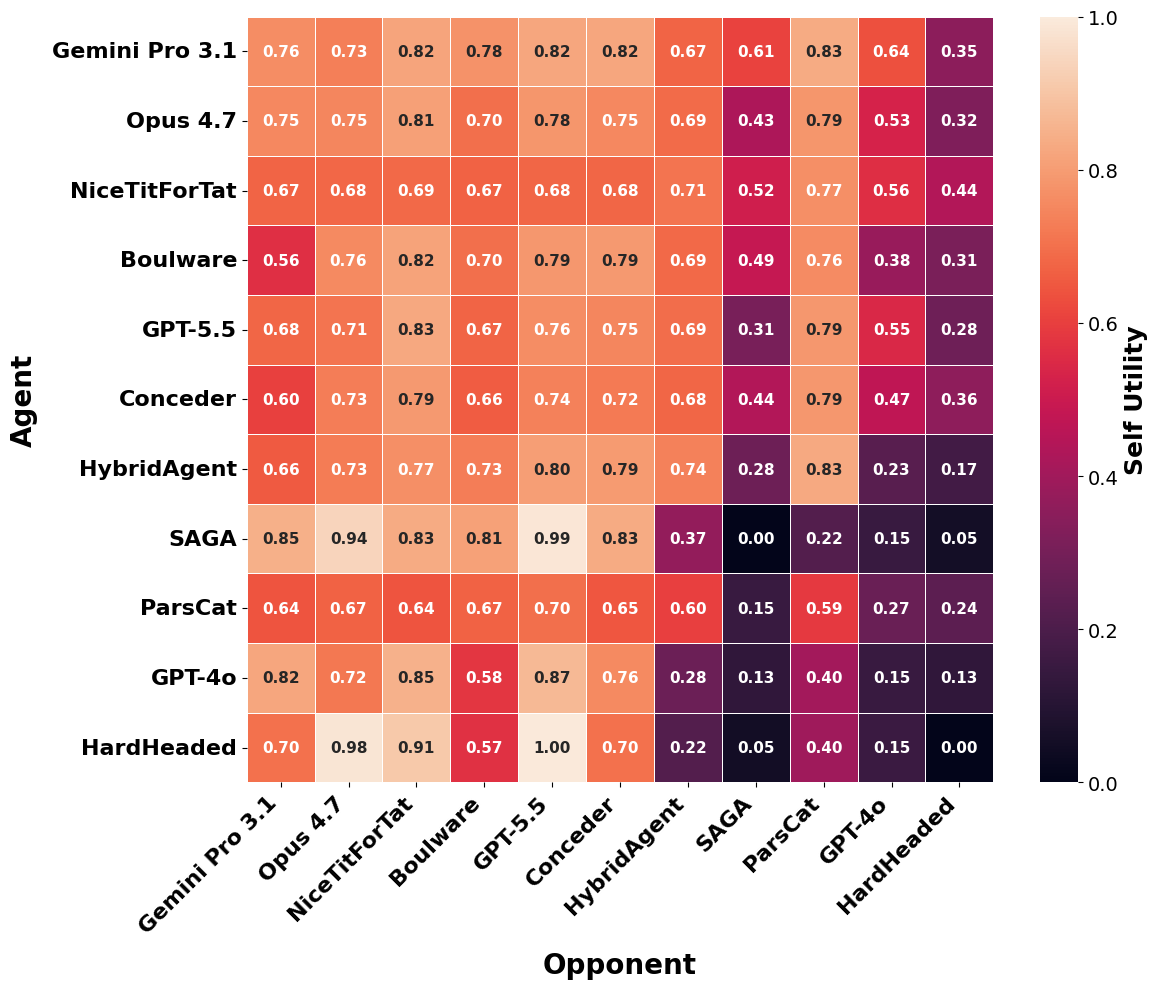

In [18]:
plot_metric_heatmap(overall_df, metric="utility")

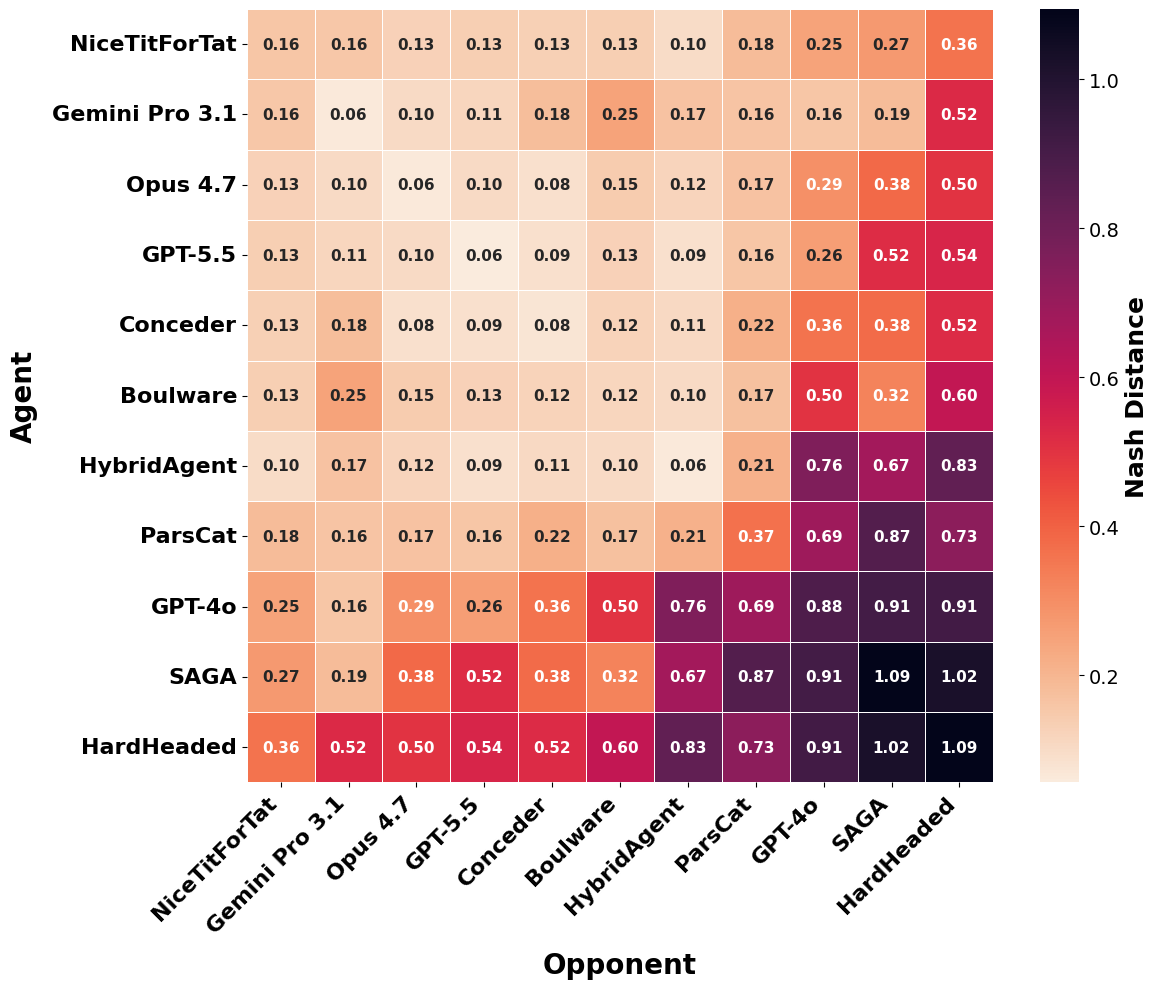

In [19]:
plot_metric_heatmap(overall_df, metric="nash")

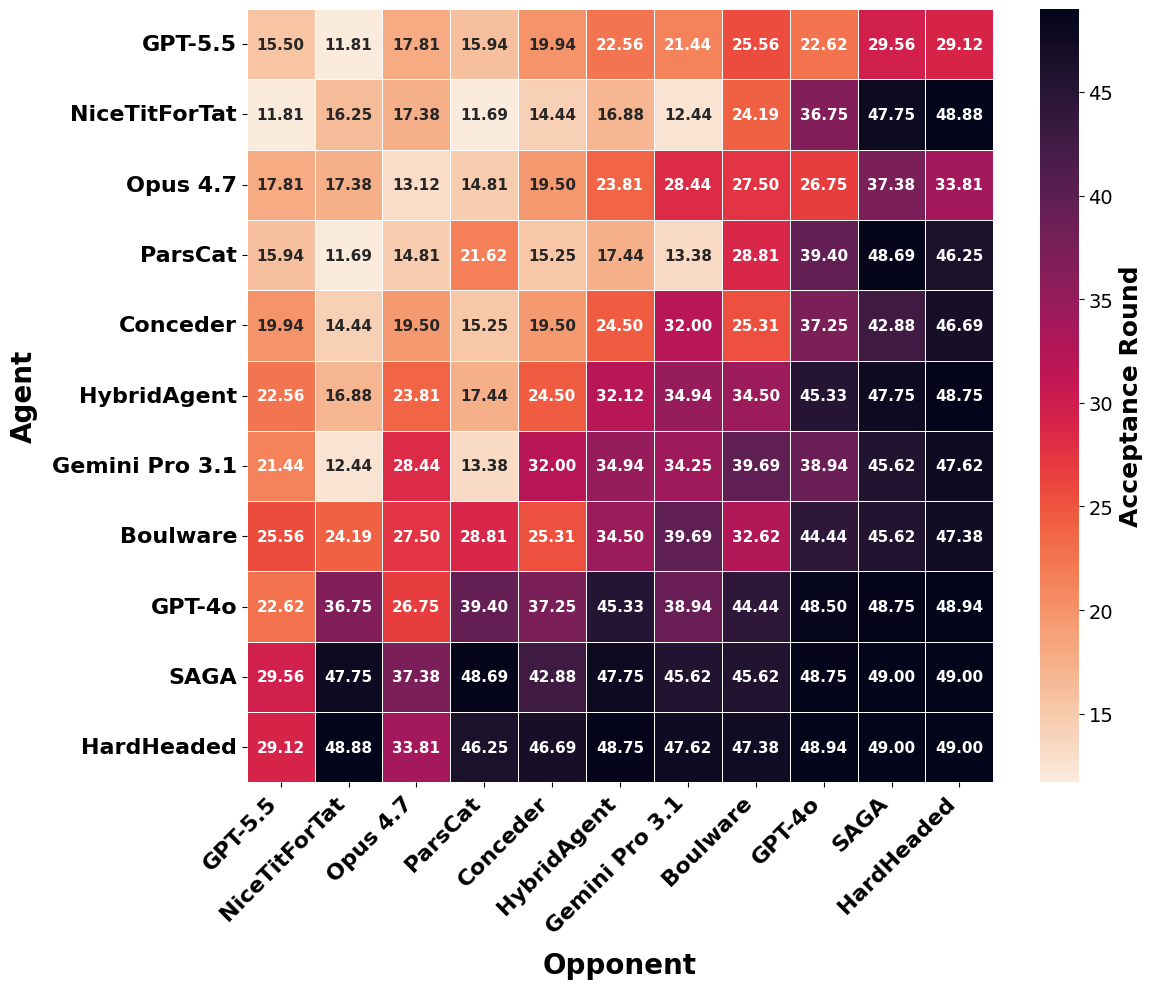

In [20]:
plot_metric_heatmap(overall_df, metric="round")

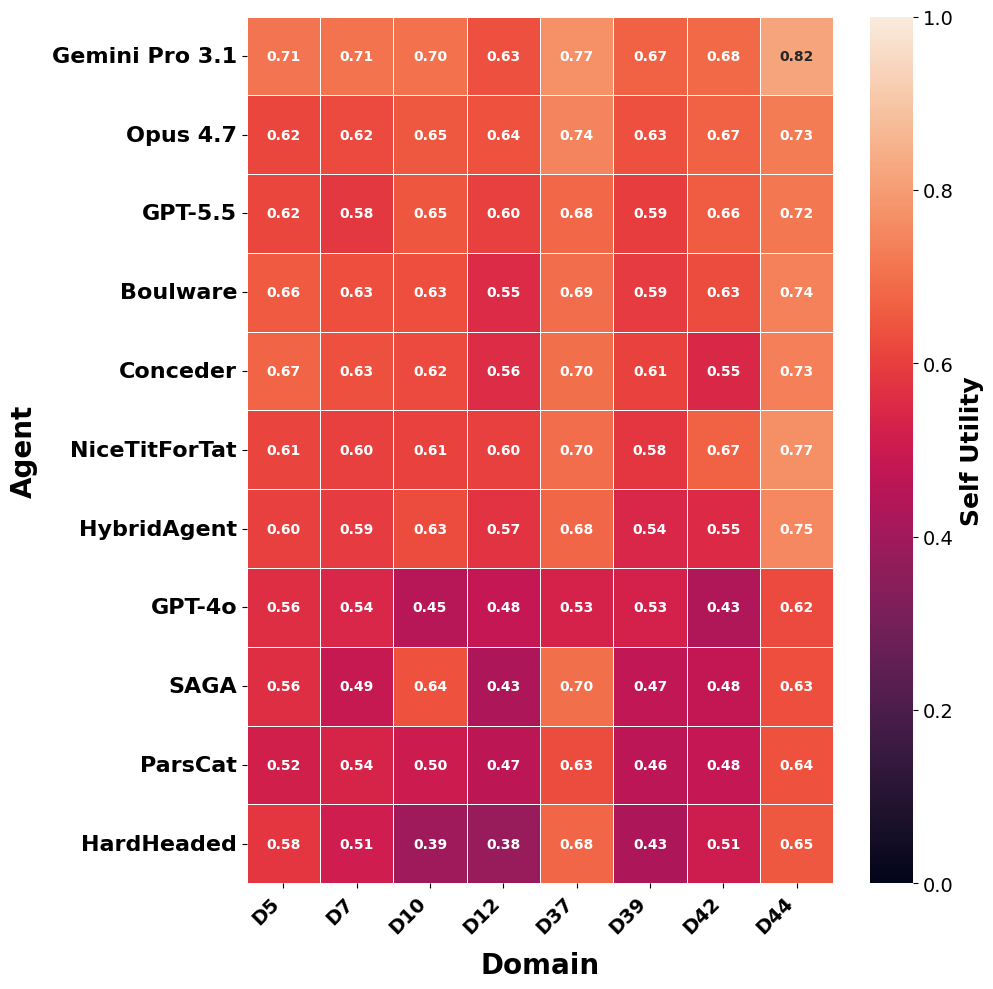

In [21]:
plot_metric_per_domain_heatmap(overall_df, metric="utility")

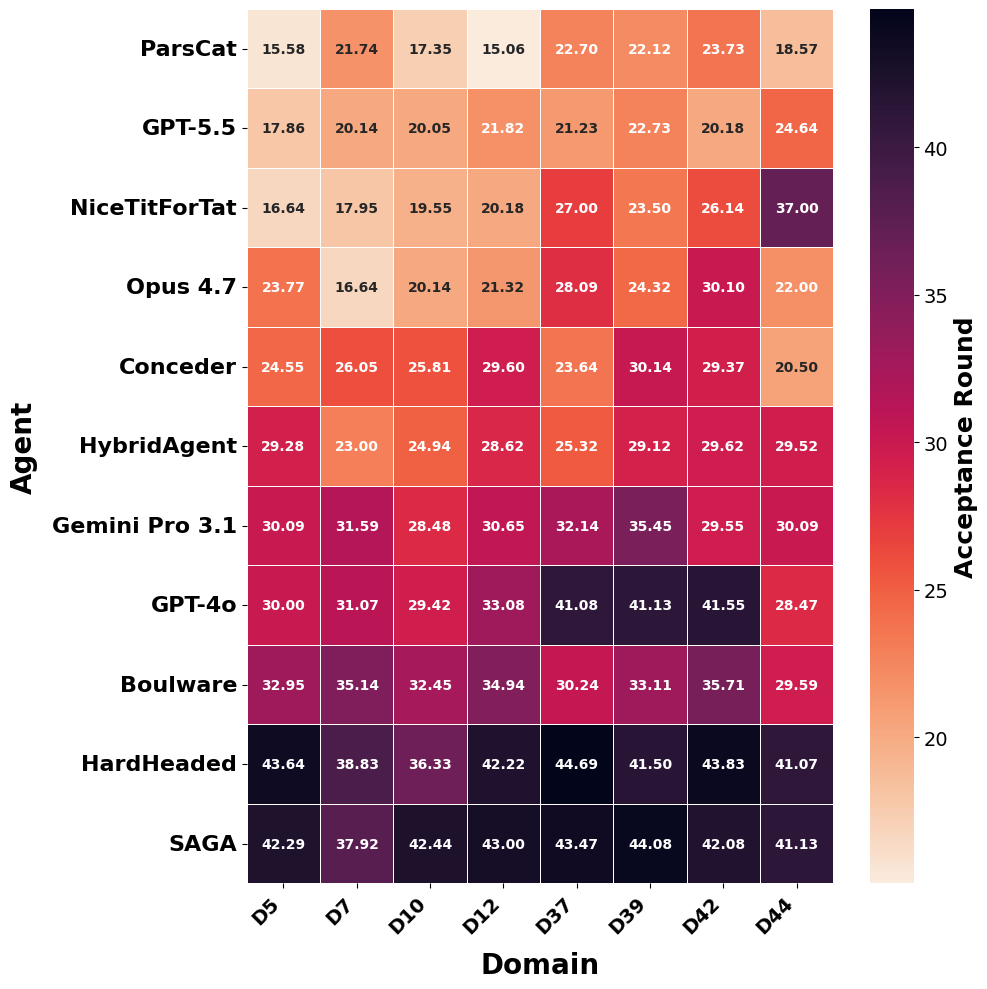

In [22]:
plot_metric_per_domain_heatmap(acceptance_df, metric="round")

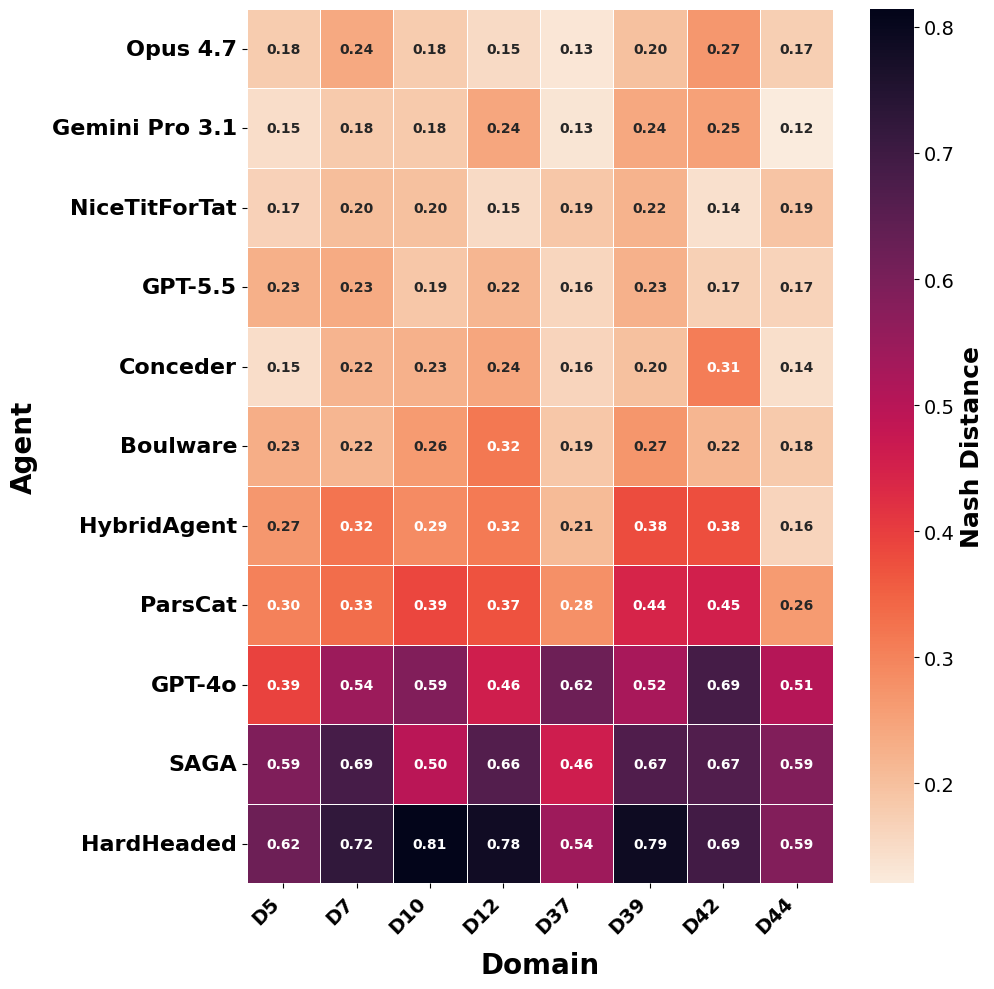

In [23]:
plot_metric_per_domain_heatmap(overall_df, metric="nash")

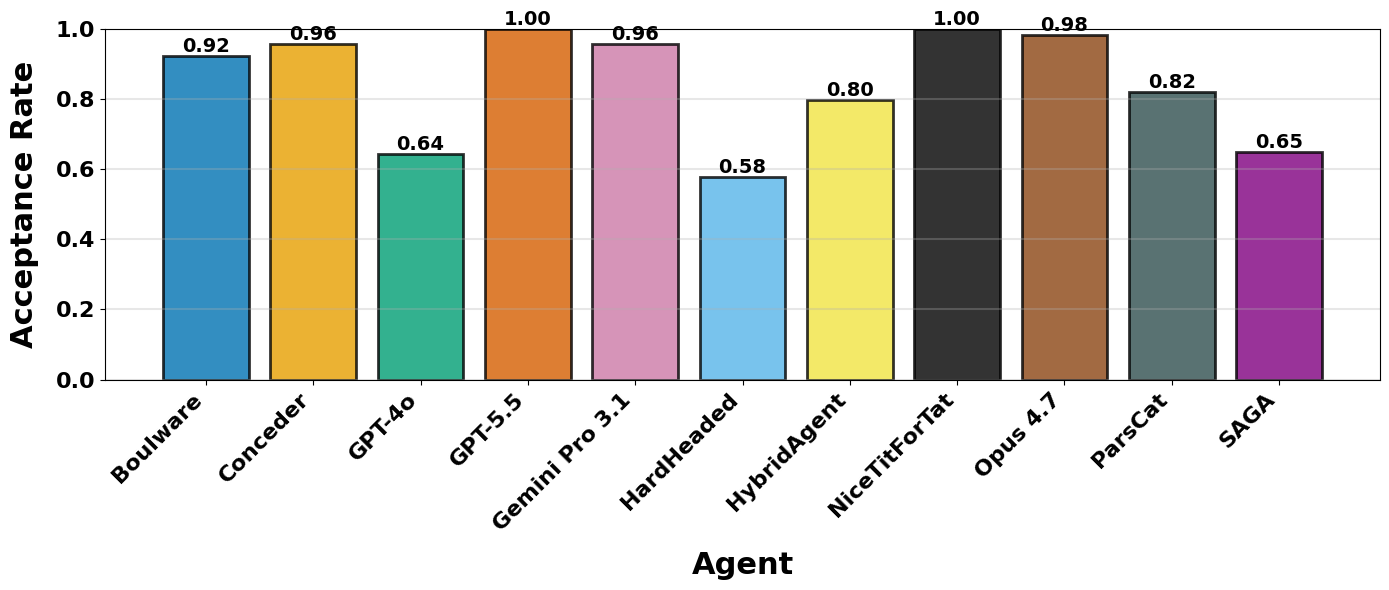

In [24]:
plot_acceptance_rate_bar(overall_df)

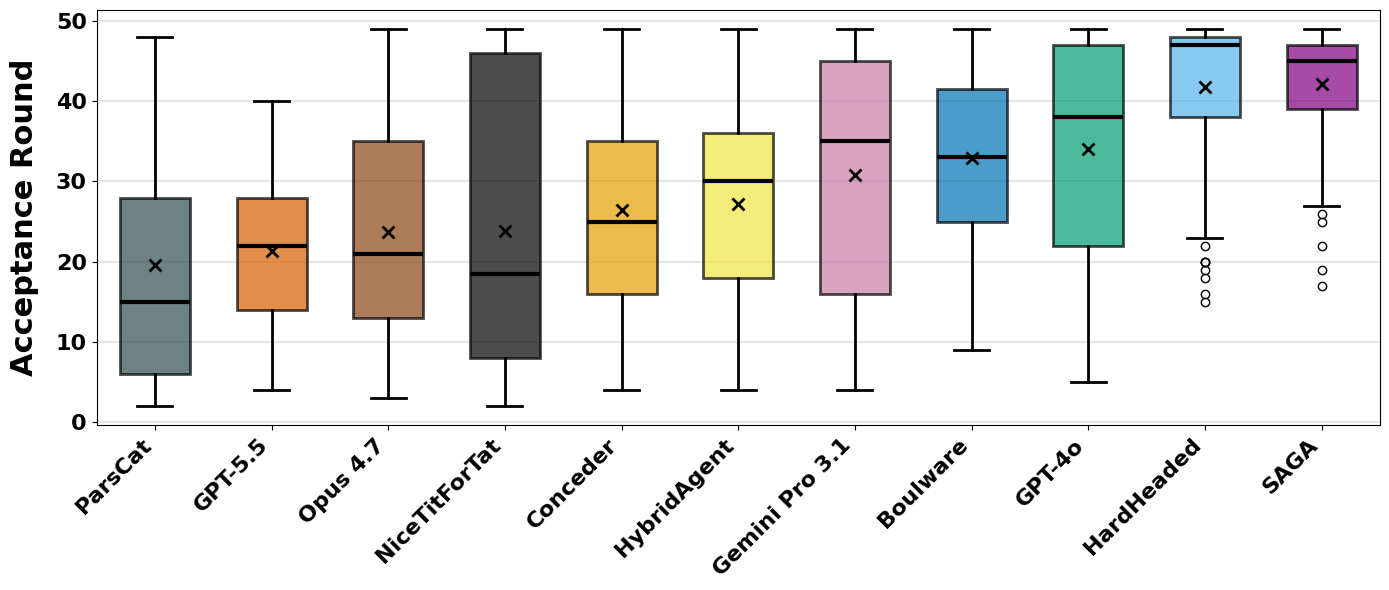

In [25]:
plot_acceptance_rounds_boxplot(acceptance_df)

# LLM Disagreements

Sessions involving an LLM-driven agent that ended in disagreement
(`Action == "Failed"`) — the deadline expired without acceptance. Useful for
spotting opponents the LLM struggles to close with.


In [26]:
# Disagreement = Action != "Accept" (process_session stamps "Failed" on
# any non-Accept terminal row). Restrict to sessions involving an LLM, using
# the Agent_*_kind columns so we don't string-match on display names.
def _is_llm_kind(k):
    return k in ("LLM", "META")


_a_is_llm = overall_df["Agent_A_kind"].apply(_is_llm_kind)
_b_is_llm = overall_df["Agent_B_kind"].apply(_is_llm_kind)
llm_disagreements = overall_df[
    (overall_df["Action"] != "Accept") & (_a_is_llm | _b_is_llm)
].copy()

# Tag the LLM side and its opponent in each row for easier inspection.
_disagree_a_is_llm = llm_disagreements["Agent_A_kind"].apply(_is_llm_kind)
llm_disagreements["LLM_Side"] = np.where(
    _disagree_a_is_llm,
    llm_disagreements["Agent_A"],
    llm_disagreements["Agent_B"],
)
llm_disagreements["Opponent"] = np.where(
    _disagree_a_is_llm,
    llm_disagreements["Agent_B"],
    llm_disagreements["Agent_A"],
)

print(f"Total LLM-side sessions: {(_a_is_llm | _b_is_llm).sum()}")
print(f"LLM disagreements:       {len(llm_disagreements)}")
print()
print("Disagreements per opponent:")
print(llm_disagreements["Opponent"].value_counts())
print()
print("Disagreements per LLM:")
print(llm_disagreements["LLM_Side"].value_counts())
print()
print("Disagreements per domain:")
print(llm_disagreements["Domain"].value_counts().sort_index())

llm_disagreements[[
    "Domain", "LLM_Side", "Opponent", "Round",
    "AgentAUtility", "AgentBUtility", "NashDistance",
]].sort_values(["LLM_Side", "Opponent", "Domain"]).reset_index(drop=True)


Total LLM-side sessions: 574
LLM disagreements:       67

Disagreements per opponent:
Opponent
HardHeaded     17
HybridAgent    13
SAGA           13
ParsCat         8
GPT-4o          6
Boulware        6
Conceder        2
Opus 4.7        2
Name: count, dtype: int64

Disagreements per LLM:
LLM_Side
GPT-4o            59
Gemini Pro 3.1     7
Opus 4.7           1
Name: count, dtype: int64

Disagreements per domain:
Domain
10    10
12     9
37     8
39     9
42    13
44     6
5      5
7      7
Name: count, dtype: int64


,Domain,LLM_Side,Opponent,Round,AgentAUtility,AgentBUtility,NashDistance
0,12,GPT-4o,Boulware,49,0.0,0.0,1.018485
1,37,GPT-4o,Boulware,49,0.0,0.0,1.152698
2,39,GPT-4o,Boulware,49,0.0,0.0,1.066486
3,42,GPT-4o,Boulware,49,0.0,0.0,1.119005
4,7,GPT-4o,Boulware,49,0.0,0.0,1.074802
...,...,...,...,...,...,...,...
62,39,Gemini Pro 3.1,HardHeaded,49,0.0,0.0,1.066486
63,42,Gemini Pro 3.1,HardHeaded,49,0.0,0.0,1.119005
64,39,Gemini Pro 3.1,HybridAgent,49,0.0,0.0,1.066486
65,42,Gemini Pro 3.1,HybridAgent,49,0.0,0.0,1.119005


# Adversary Robustness

How does each LLM perform across:
1. **Base Boulware** (`Boulware`) — Boulware bidder, no dialogue.
2. **Adversary personas** (`Adversary-{threat, emotional, positive, aggression,
   constraints, urgency, injection}`) — Boulware bidder, with persona-flavoured
   messages attached to every offer.

Bidding behaviour is fixed across all conditions (same Boulware curve), so any
utility difference between the LLM-vs-Boulware baseline and an LLM-vs-Adversary
cell is attributable to the dialogue channel — i.e. how much the LLM is
influenced (or fooled) by the persona's messages.


In [27]:
# Use adv_sessions_df (split off in the loader) plus the LLM-vs-base-Boulware
# rows from overall_df. Same Boulware bidding on the opponent side across all
# conditions, so any difference is attributable to the dialogue channel.

_BASELINE_OPP = "Boulware"
# Canonical order matches the persona table in the paper. Any adversary in
# the data that's not in this list (e.g. legacy 'Adversary-aggression' runs
# that fall back to that literal display name) is silently excluded.
_ADVERSARY_DISPLAY_ORDER = [
    "Emotional Appeal",
    "Coercive Threat",
    "Deceptive Cooperation",
    "Fabricated Constraints",
    "Manufactured Urgency",
    "Prompt Injection",
]
_adv_in_data = (
    set(adv_sessions_df.loc[adv_sessions_df["Agent_A_kind"] == "ADV", "Agent_A"])
    .union(adv_sessions_df.loc[adv_sessions_df["Agent_B_kind"] == "ADV", "Agent_B"])
)
_adv_agents = [a for a in _ADVERSARY_DISPLAY_ORDER if a in _adv_in_data]
_OPPONENTS_OF_INTEREST = (_BASELINE_OPP,) + tuple(_adv_agents)


def _row_iter(df):
    for _, r in df.iterrows():
        yield r


# 1) LLM vs base Boulware (from overall_df).
rows = []
for r in _row_iter(overall_df):
    a_kind, b_kind = r["Agent_A_kind"], r["Agent_B_kind"]
    a, b = r["Agent_A"], r["Agent_B"]
    if a_kind == "LLM" and b_kind == "TRAD" and b == _BASELINE_OPP:
        llm, opp, llm_util, opp_util = a, b, r["AgentAUtility"], r["AgentBUtility"]
    elif b_kind == "LLM" and a_kind == "TRAD" and a == _BASELINE_OPP:
        llm, opp, llm_util, opp_util = b, a, r["AgentBUtility"], r["AgentAUtility"]
    else:
        continue
    rows.append({
        "LLM": llm, "Opponent": opp, "Domain": r["Domain"],
        "LLM_Utility": llm_util, "Opp_Utility": opp_util,
        "NashDistance": r["NashDistance"], "Round": r["Round"],
        "Accepted": r["Action"] == "Accept",
    })

# 2) LLM vs each adversary persona (from adv_sessions_df). Drop any persona
# not in the canonical order (covers legacy 'Adversary-aggression' rows).
for r in _row_iter(adv_sessions_df):
    a_kind, b_kind = r["Agent_A_kind"], r["Agent_B_kind"]
    a, b = r["Agent_A"], r["Agent_B"]
    if a_kind == "LLM" and b_kind == "ADV":
        llm, opp, llm_util, opp_util = a, b, r["AgentAUtility"], r["AgentBUtility"]
    elif b_kind == "LLM" and a_kind == "ADV":
        llm, opp, llm_util, opp_util = b, a, r["AgentBUtility"], r["AgentAUtility"]
    else:
        continue
    if opp not in _ADVERSARY_DISPLAY_ORDER:
        continue
    rows.append({
        "LLM": llm, "Opponent": opp, "Domain": r["Domain"],
        "LLM_Utility": llm_util, "Opp_Utility": opp_util,
        "NashDistance": r["NashDistance"], "Round": r["Round"],
        "Accepted": r["Action"] == "Accept",
    })

adv_df = pd.DataFrame(rows)
print(f"{len(adv_df)} LLM-vs-(Boulware|Adversary) sessions")
print(adv_df["Opponent"].value_counts())

# Filter to domains where every adversary session reached agreement, then
# tighten further to domains where every (LLM, opponent) cell agreed. This
# keeps the utility/Nash tables on a fully-paired subset.
adversary_sessions = adv_df[adv_df['Opponent'] != 'Boulware']
domains_with_all_adversary_agreements = adversary_sessions.groupby('Domain')['Accepted'].all()
domains_to_keep = domains_with_all_adversary_agreements[domains_with_all_adversary_agreements].index
adv_df = adv_df[adv_df['Domain'].isin(domains_to_keep)]
print(f"After filtering for domains with all adversary agreements: {len(adv_df)} sessions")
print(f"Domains kept: {sorted(domains_to_keep)}")

domains_with_all_agreements = adv_df.groupby('Domain')['Accepted'].all()
domains_to_keep = domains_with_all_agreements[domains_with_all_agreements].index
adv_df = adv_df[adv_df['Domain'].isin(domains_to_keep)]
print(f"After filtering for domains with all agreements: {len(adv_df)} sessions")
print(f"Domains kept: {sorted(domains_to_keep)}")


447 LLM-vs-(Boulware|Adversary) sessions
Opponent
Boulware                  64
Manufactured Urgency      64
Coercive Threat           64
Emotional Appeal          64
Fabricated Constraints    64
Deceptive Cooperation     64
Prompt Injection          63
Name: count, dtype: int64
After filtering for domains with all adversary agreements: 112 sessions
Domains kept: ['37', '44']
After filtering for domains with all agreements: 56 sessions
Domains kept: ['44']


In [28]:
# Per-LLM, per-opponent mean ± std. Rows are the LLM models; columns are the
# opponent conditions (Boulware baseline first, then each adversary persona).
# One table per metric so robustness reads off each axis directly.
from IPython.display import display

_metrics_to_show = [
    ("LLM_Utility",  "LLM utility"),
    ("Opp_Utility",  "Opponent utility"),
    ("NashDistance", "Nash distance"),
]

llm_order = sorted(adv_df["LLM"].unique())

for value_col, title in _metrics_to_show:
    print(f"=== {title} (mean ± std per LLM × opponent) ===")
    table = mean_std_pivot(
        adv_df,
        row_col="LLM",
        col_col="Opponent",
        value_col=value_col,
        row_order=llm_order,
        col_order=list(_OPPONENTS_OF_INTEREST),
    )
    display(table)
    print()

# Agreement rate is a 0/1 outcome — show mean only (its std collapses to a
# binomial spread, not a calibration metric).
print("=== Agreement rate (per LLM across all adversaries) ===")
agree_table = pd.DataFrame(index=llm_order, columns=["Adversary Agreement Rate"], dtype=object)
for llm in llm_order:
    sub = adv_df[(adv_df["LLM"] == llm) & (adv_df["Opponent"] != "Boulware")]["Accepted"]
    agree_table.loc[llm, "Adversary Agreement Rate"] = f"{sub.mean():.3f}" if len(sub) else "—"
display(agree_table)


=== LLM utility (mean ± std per LLM × opponent) ===


,Boulware,Emotional Appeal,Coercive Threat,Deceptive Cooperation,Fabricated Constraints,Manufactured Urgency,Prompt Injection
GPT-4o,0.895 ± 0.149,0.890 ± 0.054,0.912 ± 0.078,0.942 ± 0.020,0.863 ± 0.041,0.911 ± 0.024,0.936 ± 0.045
GPT-5.5,0.807 ± 0.059,0.807 ± 0.059,0.760 ± 0.125,0.838 ± 0.014,0.850 ± 0.003,0.790 ± 0.082,0.854 ± 0.008
Gemini Pro 3.1,0.854 ± 0.008,0.842 ± 0.009,0.840 ± 0.028,0.894 ± 0.048,0.854 ± 0.008,0.854 ± 0.008,0.854 ± 0.008
Opus 4.7,0.790 ± 0.082,0.790 ± 0.082,0.742 ± 0.014,0.790 ± 0.082,0.802 ± 0.065,0.790 ± 0.082,0.810 ± 0.110



=== Opponent utility (mean ± std per LLM × opponent) ===


,Boulware,Emotional Appeal,Coercive Threat,Deceptive Cooperation,Fabricated Constraints,Manufactured Urgency,Prompt Injection
GPT-4o,0.654 ± 0.275,0.746 ± 0.020,0.484 ± 0.091,0.658 ± 0.105,0.559 ± 0.127,0.702 ± 0.042,0.558 ± 0.014
GPT-5.5,0.819 ± 0.042,0.819 ± 0.042,0.847 ± 0.082,0.775 ± 0.021,0.775 ± 0.021,0.859 ± 0.098,0.771 ± 0.026
Gemini Pro 3.1,0.759 ± 0.009,0.771 ± 0.026,0.759 ± 0.009,0.754 ± 0.003,0.771 ± 0.026,0.771 ± 0.026,0.771 ± 0.026
Opus 4.7,0.847 ± 0.115,0.847 ± 0.115,0.882 ± 0.065,0.847 ± 0.115,0.847 ± 0.115,0.859 ± 0.098,0.743 ± 0.262



=== Nash distance (mean ± std per LLM × opponent) ===


,Boulware,Emotional Appeal,Coercive Threat,Deceptive Cooperation,Fabricated Constraints,Manufactured Urgency,Prompt Injection
GPT-4o,0.196 ± 0.154,0.109 ± 0.120,0.365 ± 0.217,0.211 ± 0.264,0.289 ± 0.001,0.157 ± 0.188,0.300 ± 0.126
GPT-5.5,0.083 ± 0.004,0.083 ± 0.004,0.087 ± 0.000,0.135 ± 0.068,0.140 ± 0.076,0.055 ± 0.044,0.146 ± 0.083
Gemini Pro 3.1,0.142 ± 0.088,0.140 ± 0.075,0.157 ± 0.068,0.102 ± 0.145,0.146 ± 0.083,0.146 ± 0.083,0.146 ± 0.083
Opus 4.7,0.052 ± 0.040,0.052 ± 0.040,0.109 ± 0.120,0.052 ± 0.040,0.040 ± 0.057,0.055 ± 0.044,0.113 ± 0.126



=== Agreement rate (per LLM across all adversaries) ===


,Adversary Agreement Rate
GPT-4o,1.000
GPT-5.5,1.000
Gemini Pro 3.1,1.000
Opus 4.7,1.000


In [29]:
# Per-LLM × per-adversary acceptance rate. Computed over EVERY adversary
# session — no domain filtering — since agreement is itself the outcome we
# want to measure across attacks.
print("=== Acceptance rate (per LLM × adversary, all sessions) ===")

_a_is_llm = adv_sessions_df["Agent_A_kind"] == "LLM"
_a_is_adv = adv_sessions_df["Agent_A_kind"] == "ADV"
_llm_col = np.where(_a_is_llm, adv_sessions_df["Agent_A"], adv_sessions_df["Agent_B"])
_adv_col = np.where(_a_is_adv, adv_sessions_df["Agent_A"], adv_sessions_df["Agent_B"])
_acc_col = (adv_sessions_df["Action"] == "Accept").astype(float)

_acc_long = pd.DataFrame({
    "LLM": _llm_col,
    "Adversary": _adv_col,
    "Accepted": _acc_col,
})
_acc_long = _acc_long[_acc_long["Adversary"].isin(_ADVERSARY_DISPLAY_ORDER)]

acceptance_table = (
    _acc_long
    .pivot_table(index="LLM", columns="Adversary", values="Accepted", aggfunc="mean")
    .reindex(index=llm_order, columns=_ADVERSARY_DISPLAY_ORDER)
)
display(acceptance_table.map(lambda v: f"{v:.3f}" if pd.notna(v) else "—"))


=== Acceptance rate (per LLM × adversary, all sessions) ===


Adversary,Emotional Appeal,Coercive Threat,Deceptive Cooperation,Fabricated Constraints,Manufactured Urgency,Prompt Injection
LLM,,,,,,
GPT-4o,0.688,0.875,0.812,0.938,0.812,0.867
GPT-5.5,1.000,1.000,1.000,1.000,1.000,1.000
Gemini Pro 3.1,1.000,1.000,1.000,1.000,1.000,1.000
Opus 4.7,1.000,1.000,1.000,1.000,1.000,1.000


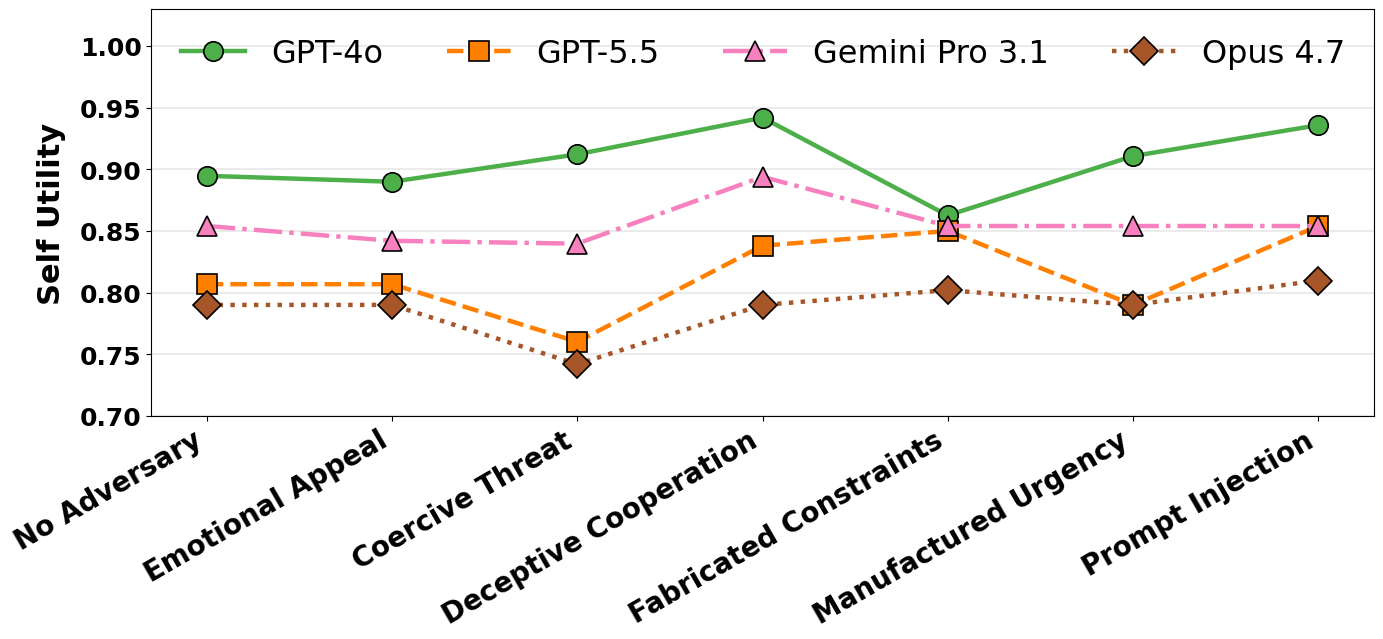

In [30]:
# Self-utility line plot: one line per LLM, x-axis is the opponent condition
# (base Boulware first, relabelled "No Adversary"; then each adversary
# persona under its paper-table display name).
#
# Uses a hand-picked high-contrast palette (ColorBrewer "Set1"-inspired) plus
# rotating linestyles + marker shapes so adjacent LLMs stay distinguishable
# even when the figure is shrunk for the paper.
_LINE_PALETTE = [
    "#E41A1C",  # vivid red
    "#377EB8",  # strong blue
    "#4DAF4A",  # vivid green
    "#984EA3",  # purple
    "#FF7F00",  # vivid orange
    "#A65628",  # brown
    "#F781BF",  # pink
    "#000000",  # black
    "#17BECF",  # cyan
    "#BCBD22",  # olive
]
_LLM_COLOR_MAP = {
    "GPT-4o":         "#4DAF4A",  # green
    "GPT-5.5":        "#FF7F00",  # orange
    "Gemini Pro 3.1": "#F781BF",  # pink
    "Opus 4.7":       "#A65628",  # brown
}
_LINESTYLES = ["-", "--", "-.", ":"]
_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<"]


def _format_opponent(opp: str) -> str:
    if opp == "Boulware":
        return "No Adversary"
    return opp


def plot_adversary_lines(adv_df, llm_order, opponents, ylim=None):
    x_labels = [_format_opponent(o) for o in opponents]
    x = np.arange(len(opponents))

    fig, ax = plt.subplots(figsize=(max(14, 1.4 * len(opponents)), 6.5))
    for i, llm in enumerate(llm_order):
        sub = adv_df[adv_df["LLM"] == llm]
        means = []
        for opp in opponents:
            cell = sub[sub["Opponent"] == opp]["LLM_Utility"]
            means.append(cell.mean() if len(cell) else np.nan)
        ax.plot(
            x, means,
            marker=_MARKERS[i % len(_MARKERS)],
            linestyle=_LINESTYLES[i % len(_LINESTYLES)],
            linewidth=3.2, markersize=14,
            color=_LLM_COLOR_MAP.get(llm, _LINE_PALETTE[i % len(_LINE_PALETTE)]),
            label=llm,
            markeredgecolor="black", markeredgewidth=1.2,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=30, ha="right")
    ax.set_ylabel("Self Utility", fontsize=22, fontweight="bold", labelpad=10)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.3, linewidth=1.2)
    ax.legend(title="", title_fontsize=18, fontsize=23,
              loc="best", frameon=False, ncol=4)
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=18)
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")
    plt.tight_layout()
    plt.show()


plot_adversary_lines(adv_df, llm_order, _OPPONENTS_OF_INTEREST,
                     ylim=(0.7, 1.03))


In [31]:
# Acceptance-rate table: rows are LLMs, columns are opponents
# (No-Adversary baseline first, then each adversary persona). Computed over
# every session — no domain filtering.
_acc_rows = []
for _, r in overall_df.iterrows():
    a_kind, b_kind = r["Agent_A_kind"], r["Agent_B_kind"]
    a, b = r["Agent_A"], r["Agent_B"]
    if a_kind == "LLM" and b_kind == "TRAD" and b == _BASELINE_OPP:
        _acc_rows.append({"LLM": a, "Opponent": b, "Accepted": r["Action"] == "Accept"})
    elif b_kind == "LLM" and a_kind == "TRAD" and a == _BASELINE_OPP:
        _acc_rows.append({"LLM": b, "Opponent": a, "Accepted": r["Action"] == "Accept"})
for _, r in adv_sessions_df.iterrows():
    a_kind, b_kind = r["Agent_A_kind"], r["Agent_B_kind"]
    a, b = r["Agent_A"], r["Agent_B"]
    if a_kind == "LLM" and b_kind == "ADV" and b in _ADVERSARY_DISPLAY_ORDER:
        _acc_rows.append({"LLM": a, "Opponent": b, "Accepted": r["Action"] == "Accept"})
    elif b_kind == "LLM" and a_kind == "ADV" and a in _ADVERSARY_DISPLAY_ORDER:
        _acc_rows.append({"LLM": b, "Opponent": a, "Accepted": r["Action"] == "Accept"})
_acc_full = pd.DataFrame(_acc_rows)

acceptance_full_table = (
    _acc_full
    .pivot_table(index="LLM", columns="Opponent", values="Accepted", aggfunc="mean")
    .reindex(index=llm_order, columns=list(_OPPONENTS_OF_INTEREST))
)
acceptance_full_table.columns = [_format_opponent(c) for c in acceptance_full_table.columns]
display(acceptance_full_table.map(lambda v: f"{v:.3f}" if pd.notna(v) else "—"))


,No Adversary,Emotional Appeal,Coercive Threat,Deceptive Cooperation,Fabricated Constraints,Manufactured Urgency,Prompt Injection
LLM,,,,,,,
GPT-4o,0.688,0.688,0.875,0.812,0.938,0.812,0.867
GPT-5.5,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Gemini Pro 3.1,0.938,1.000,1.000,1.000,1.000,1.000,1.000
Opus 4.7,1.000,1.000,1.000,1.000,1.000,1.000,1.000
